In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

development_df = pd.read_csv("../../data/processed/development_unscaled.csv")

X = development_df.drop(columns=["id", "diagnosis"]).values
y = development_df["diagnosis"].values

print(X.shape)
print(y.shape)

(455, 30)
(455,)


In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [3]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

In [4]:
def compute_loss(y, y_hat):
    epsilon = 1e-15
    y_hat = np.clip(y_hat, epsilon, 1 - epsilon)

    return -np.mean(
        y * np.log(y_hat) +
        (1 - y) * np.log(1 - y_hat)
    )

In [5]:
def initialize_parameters(n_features):
    theta = np.zeros(n_features)
    bias = 0.0

    return theta, bias

In [6]:
def compute_gradients(X, y, y_hat):
    m = X.shape[0]

    d_theta = (1 / m) * X.T @ (y_hat - y)
    d_bias = (1 / m) * np.sum(y_hat - y)

    return d_theta, d_bias

In [7]:
theta, bias = initialize_parameters(X.shape[1])

z = X @ theta + bias
y_hat = sigmoid(z)

d_theta, d_bias = compute_gradients(
    X,
    y,
    y_hat
)

print("Theta shape:", theta.shape)
print("Prediction shape:", y_hat.shape)
print("Gradient shape:", d_theta.shape)
print("Bias gradient:", d_bias)
print("Initial loss:", compute_loss(y, y_hat))

Theta shape: (30,)
Prediction shape: (455,)
Gradient shape: (30,)
Bias gradient: 0.12637362637362637
Initial loss: 0.6931471805599453


In [8]:
def train_logistic_regression(
    X,
    y,
    learning_rate=0.01,
    iterations=1000
):

    n_samples, n_features = X.shape

    theta = np.zeros(n_features)
    bias = 0.0

    loss_history = []

    for i in range(iterations):

        # Linear combination
        z = X @ theta + bias

        # Predicted probabilities
        y_hat = sigmoid(z)

        # Compute loss
        loss = compute_loss(y, y_hat)
        loss_history.append(loss)

        # Compute gradients
        d_theta, d_bias = compute_gradients(
            X,
            y,
            y_hat
        )

        # Update parameters
        theta -= learning_rate * d_theta
        bias -= learning_rate * d_bias

        # Print progress every 100 iterations
        if i % 100 == 0:
            print(f"Iteration {i}: Loss = {loss:.6f}")

    return theta, bias, loss_history

In [9]:
theta, bias, loss_history = train_logistic_regression(
    X_scaled,
    y,
    learning_rate=0.01,
    iterations=1000
)

Iteration 0: Loss = 0.693147
Iteration 100: Loss = 0.250198
Iteration 200: Loss = 0.187135
Iteration 300: Loss = 0.158738
Iteration 400: Loss = 0.142030
Iteration 500: Loss = 0.130812
Iteration 600: Loss = 0.122651
Iteration 700: Loss = 0.116385
Iteration 800: Loss = 0.111385
Iteration 900: Loss = 0.107279


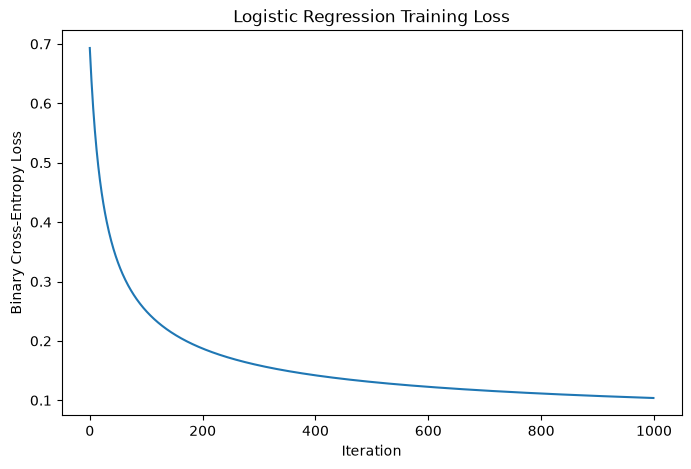

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(loss_history)
plt.xlabel("Iteration")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Logistic Regression Training Loss")
plt.show()

In [11]:
def predict_probabilities(X, theta, bias):
    z = X @ theta + bias
    return sigmoid(z)


def predict_classes(X, theta, bias, threshold=0.5):
    probabilities = predict_probabilities(X, theta, bias)
    return (probabilities >= threshold).astype(int)

In [12]:
y_pred = predict_classes(X_scaled, theta, bias)

print("First 10 predictions:", y_pred[:10])
print("First 10 actual values:", y[:10])

First 10 predictions: [1 0 0 1 1 1 0 1 0 1]
First 10 actual values: [1 0 0 1 1 1 0 1 1 1]


In [13]:
accuracy = np.mean(y_pred == y)

print(f"Development accuracy: {accuracy:.4f}")

Development accuracy: 0.9780


In [14]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [15]:
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for fold, (train_index, validation_index) in enumerate(
    skf.split(X, y),
    start=1
):
    # Separate this fold's training and validation data
    X_train_fold = X[train_index]
    X_validation_fold = X[validation_index]

    y_train_fold = y[train_index]
    y_validation_fold = y[validation_index]

    # Fit the scaler only on this fold's training data
    fold_scaler = StandardScaler()

    X_train_scaled = fold_scaler.fit_transform(X_train_fold)
    X_validation_scaled = fold_scaler.transform(X_validation_fold)

    # Train the manual logistic regression model
    fold_theta, fold_bias, fold_loss_history = train_logistic_regression(
        X_train_scaled,
        y_train_fold,
        learning_rate=0.01,
        iterations=1000
    )

    # Predict validation probabilities and classes
    validation_probabilities = predict_probabilities(
        X_validation_scaled,
        fold_theta,
        fold_bias
    )

    validation_predictions = (
        validation_probabilities >= 0.5
    ).astype(int)

    # Calculate metrics
    fold_accuracy = accuracy_score(
        y_validation_fold,
        validation_predictions
    )

    fold_precision = precision_score(
        y_validation_fold,
        validation_predictions
    )

    fold_recall = recall_score(
        y_validation_fold,
        validation_predictions
    )

    fold_f1 = f1_score(
        y_validation_fold,
        validation_predictions
    )

    fold_roc_auc = roc_auc_score(
        y_validation_fold,
        validation_probabilities
    )

    cv_results.append({
        "fold": fold,
        "accuracy": fold_accuracy,
        "precision": fold_precision,
        "recall": fold_recall,
        "f1": fold_f1,
        "roc_auc": fold_roc_auc
    })

    print(
        f"Fold {fold}: "
        f"Accuracy = {fold_accuracy:.4f}, "
        f"Precision = {fold_precision:.4f}, "
        f"Recall = {fold_recall:.4f}, "
        f"F1 = {fold_f1:.4f}, "
        f"ROC-AUC = {fold_roc_auc:.4f}"
    )

Iteration 0: Loss = 0.693147
Iteration 100: Loss = 0.249603
Iteration 200: Loss = 0.185788
Iteration 300: Loss = 0.156869
Iteration 400: Loss = 0.139774
Iteration 500: Loss = 0.128243
Iteration 600: Loss = 0.119818
Iteration 700: Loss = 0.113324
Iteration 800: Loss = 0.108125
Iteration 900: Loss = 0.103842
Fold 1: Accuracy = 0.9670, Precision = 1.0000, Recall = 0.9118, F1 = 0.9538, ROC-AUC = 0.9959
Iteration 0: Loss = 0.693147
Iteration 100: Loss = 0.262108
Iteration 200: Loss = 0.198193
Iteration 300: Loss = 0.168991
Iteration 400: Loss = 0.151644
Iteration 500: Loss = 0.139911
Iteration 600: Loss = 0.131328
Iteration 700: Loss = 0.124711
Iteration 800: Loss = 0.119414
Iteration 900: Loss = 0.115054
Fold 2: Accuracy = 0.9780, Precision = 0.9444, Recall = 1.0000, F1 = 0.9714, ROC-AUC = 0.9990
Iteration 0: Loss = 0.693147
Iteration 100: Loss = 0.245191
Iteration 200: Loss = 0.183380
Iteration 300: Loss = 0.155809
Iteration 400: Loss = 0.139718
Iteration 500: Loss = 0.129029
Iteration 60

In [16]:
cv_results_df = pd.DataFrame(cv_results)

display(cv_results_df)

print("\nMean cross-validation results:")

for metric in ["accuracy", "precision", "recall", "f1", "roc_auc"]:
    mean_value = cv_results_df[metric].mean()
    std_value = cv_results_df[metric].std()

    print(
        f"{metric.capitalize()}: "
        f"{mean_value:.4f} ± {std_value:.4f}"
    )

,fold,accuracy,precision,recall,f1,roc_auc
0,1,0.967033,1.000000,0.911765,0.953846,0.995872
1,2,0.978022,0.944444,1.000000,0.971429,0.998968
2,3,0.978022,1.000000,0.941176,0.969697,0.997936
3,4,0.978022,1.000000,0.941176,0.969697,0.982456
4,5,0.989011,1.000000,0.970588,0.985075,0.995356



Mean cross-validation results:
Accuracy: 0.9780 ± 0.0078
Precision: 0.9889 ± 0.0248
Recall: 0.9529 ± 0.0335
F1: 0.9699 ± 0.0111
Roc_auc: 0.9941 ± 0.0067


In [17]:
X_train_scaled = fold_scaler.fit_transform(X_train_fold)

In [18]:
X_validation_scaled = fold_scaler.transform(X_validation_fold)

In [19]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold

In [20]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", np.unique(y))

X shape: (455, 30)
y shape: (455,)
Classes: [0 1]


In [21]:
logistic_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    (
        "logreg",
        LogisticRegression(
            solver="lbfgs",
            max_iter=5000,
            random_state=42
        )
    )
])

parameter_grid = {
    "logreg__C": [0.01, 0.1, 1, 10, 100],
    "logreg__class_weight": [None, "balanced"]
}

In [22]:
grid_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

logistic_grid_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=parameter_grid,
    scoring="roc_auc",
    cv=grid_cv,
    refit=True,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

In [23]:
logistic_grid_search.fit(X, y)

Fitting 5 folds for each of 10 candidates, totalling 50 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'logreg__C': [0.01, 0.1, ...], 'logreg__class_weight': [None, 'balanced']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the 

In [24]:
print("Best parameters:")
print(logistic_grid_search.best_params_)

print(
    "Best mean cross-validation ROC-AUC:",
    round(logistic_grid_search.best_score_, 4)
)

Best parameters:
{'logreg__C': 1, 'logreg__class_weight': None}
Best mean cross-validation ROC-AUC: 0.9958


In [25]:
grid_results_df = pd.DataFrame(
    logistic_grid_search.cv_results_
)

grid_summary = grid_results_df[[
    "param_logreg__C",
    "param_logreg__class_weight",
    "mean_test_score",
    "std_test_score",
    "mean_train_score"
]].sort_values(
    by="mean_test_score",
    ascending=False
).reset_index(drop=True)

display(grid_summary)

,param_logreg__C,param_logreg__class_weight,mean_test_score,std_test_score,mean_train_score
0,1.00,NaN,0.995769,0.004666,0.997691
1,1.00,balanced,0.995356,0.004752,0.998020
2,0.10,NaN,0.994943,0.005599,0.995840
3,0.10,balanced,0.994737,0.005494,0.996098
4,10.00,NaN,0.994324,0.003605,0.999639
5,10.00,balanced,0.993808,0.003721,0.999761
6,100.00,balanced,0.992054,0.004212,0.999987
7,0.01,balanced,0.991538,0.008613,0.993111
8,100.00,NaN,0.991434,0.005166,0.999987
9,0.01,NaN,0.991125,0.008981,0.992770


In [26]:
best_logistic_model = logistic_grid_search.best_estimator_

print(best_logistic_model)

Pipeline(steps=[('scaler', StandardScaler()),
                ('logreg',
                 LogisticRegression(C=1, max_iter=5000, random_state=42))])


In [ ]:
test_df = pd.read_csv("../../data/processed/test_unscaled_FINAL_HOLDOUT.csv")

X_test = test_df.drop(columns=["id", "diagnosis"])
y_test = test_df["diagnosis"].values

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)
print("\nHoldout class counts:")
print(test_df["diagnosis"].value_counts())

X_test shape: (114, 30)
y_test shape: (114,)

Holdout class counts:
diagnosis
0    72
1    42
Name: count, dtype: int64


In [28]:
tuned_test_predictions = best_logistic_model.predict(X_test)

tuned_test_probabilities = best_logistic_model.predict_proba(
    X_test
)[:, 1]

print("Prediction shape:", tuned_test_predictions.shape)
print("Probability shape:", tuned_test_probabilities.shape)

print("\nFirst 10 predictions:")
print(tuned_test_predictions[:10])

print("\nFirst 10 malignant probabilities:")
print(np.round(tuned_test_probabilities[:10], 4))

Prediction shape: (114,)
Probability shape: (114,)

First 10 predictions:
[0 1 0 1 1 0 1 0 0 0]

First 10 malignant probabilities:
[4.000e-04 1.000e+00 4.260e-02 5.762e-01 5.092e-01 6.000e-04 7.615e-01
 1.000e-03 6.000e-04 1.080e-02]


c:\Users\Owner\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
c:\Users\Owner\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(


In [29]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

tuned_accuracy = accuracy_score(
    y_test,
    tuned_test_predictions
)

tuned_precision = precision_score(
    y_test,
    tuned_test_predictions
)

tuned_recall = recall_score(
    y_test,
    tuned_test_predictions
)

tuned_f1 = f1_score(
    y_test,
    tuned_test_predictions
)

tuned_roc_auc = roc_auc_score(
    y_test,
    tuned_test_probabilities
)

print("Tuned Logistic Regression Holdout Results")
print("------------------------------------------")
print("Accuracy:", round(tuned_accuracy, 4))
print("Precision:", round(tuned_precision, 4))
print("Recall:", round(tuned_recall, 4))
print("F1 Score:", round(tuned_f1, 4))
print("ROC-AUC:", round(tuned_roc_auc, 4))

Tuned Logistic Regression Holdout Results
------------------------------------------
Accuracy: 0.9649
Precision: 0.975
Recall: 0.9286
F1 Score: 0.9512
ROC-AUC: 0.996


Confusion Matrix:
[[71  1]
 [ 3 39]]

True Negatives: 71
False Positives: 1
False Negatives: 3
True Positives: 39


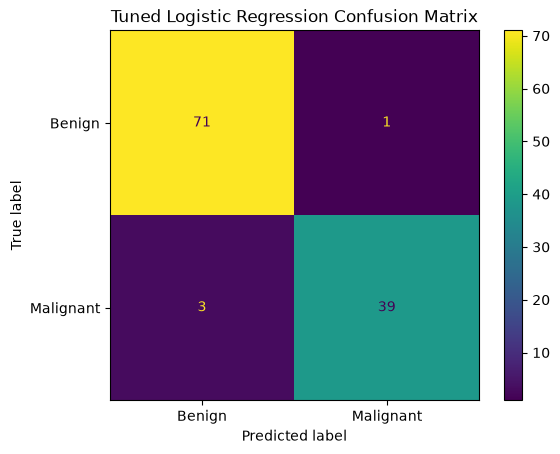

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(
    y_test,
    tuned_test_predictions
)

print("Confusion Matrix:")
print(cm)

tn, fp, fn, tp = cm.ravel()

print("\nTrue Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)

cm_display.plot()
plt.title("Tuned Logistic Regression Confusion Matrix")
plt.show()

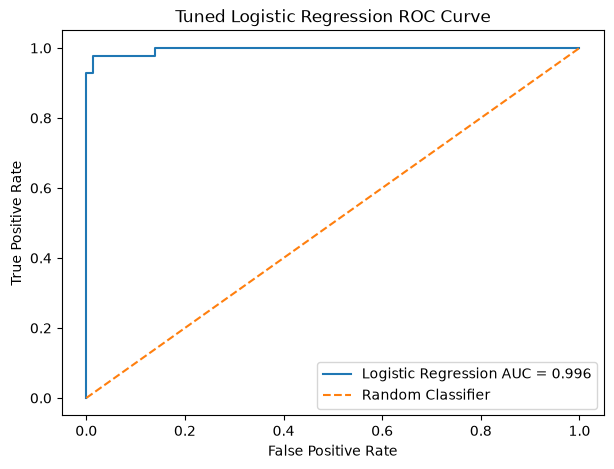

In [31]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    tuned_test_probabilities
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label="Logistic Regression AUC = "
    + str(round(tuned_roc_auc, 3))
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Tuned Logistic Regression ROC Curve")
plt.legend()
plt.show()

In [32]:
import shap

tuned_scaler = best_logistic_model.named_steps["scaler"]
tuned_logreg = best_logistic_model.named_steps["logreg"]

feature_names = development_df.drop(
    columns=["id", "diagnosis"]
).columns

X_development_scaled_for_shap = tuned_scaler.transform(X)

X_test_scaled_for_shap = tuned_scaler.transform(
    X_test.values
)

X_development_shap_df = pd.DataFrame(
    X_development_scaled_for_shap,
    columns=feature_names
)

X_test_shap_df = pd.DataFrame(
    X_test_scaled_for_shap,
    columns=feature_names
)

print("Development SHAP data shape:",
      X_development_shap_df.shape)

print("Test SHAP data shape:",
      X_test_shap_df.shape)

Development SHAP data shape: (455, 30)
Test SHAP data shape: (114, 30)


Background dataset has 455 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=455 when initializing the masker.


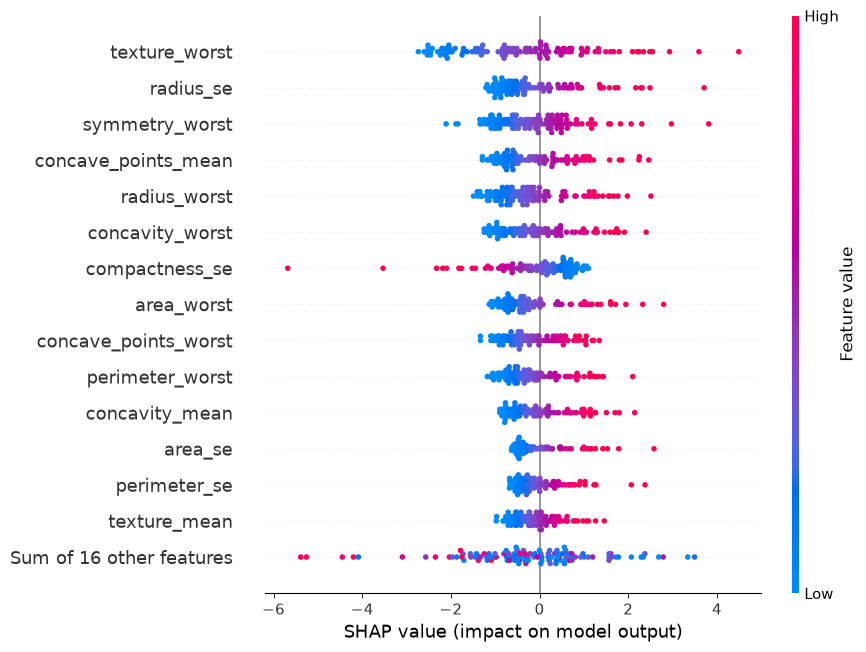

In [33]:
shap_explainer = shap.LinearExplainer(
    tuned_logreg,
    X_development_shap_df
)

shap_values = shap_explainer(
    X_test_shap_df
)

shap.plots.beeswarm(
    shap_values,
    max_display=15
)